In [39]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/bike_sharing_demand.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
for col in df.iloc[:, 1:5]:
    print(col, df[col].unique())

season [1 2 3 4]
holiday [0 1]
workingday [0 1]
weather [1 2 3 4]


### 📈 Features Outliers Checking

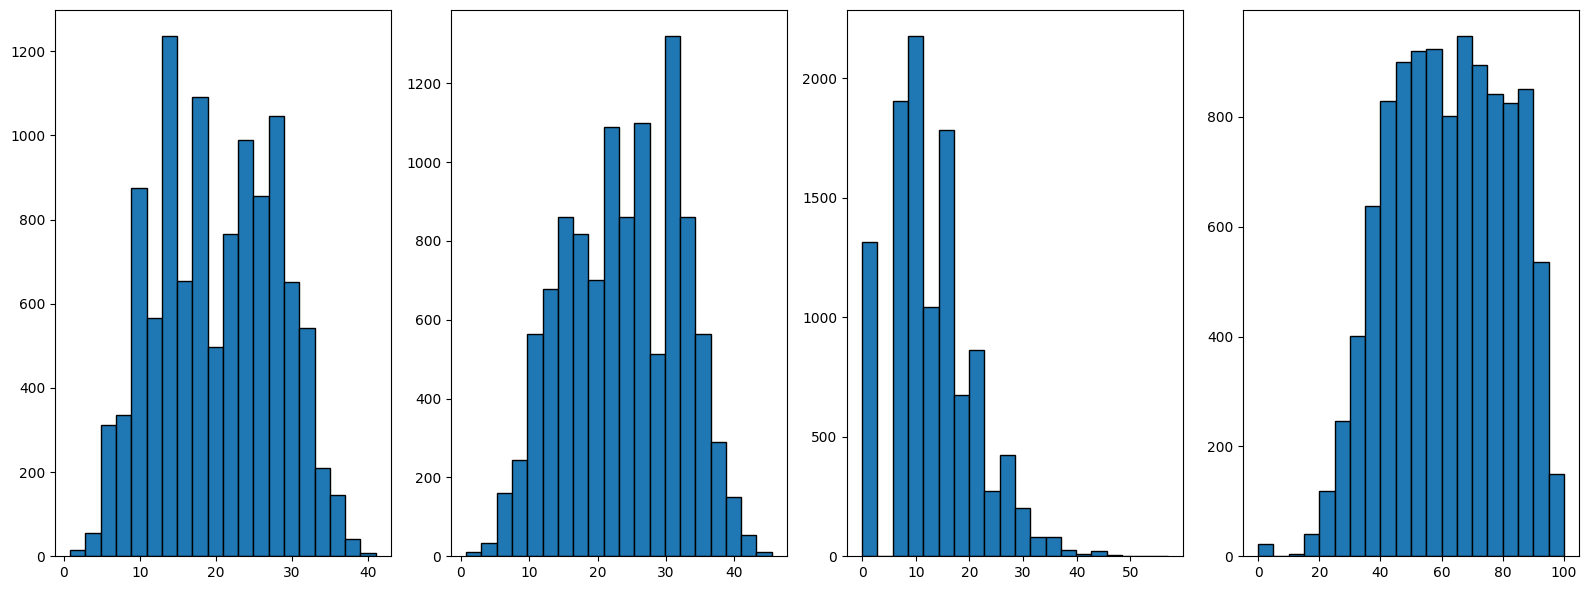

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,4, figsize=(16,6))

axes[0].hist(df['temp'], bins=20, edgecolor='black')
axes[1].hist(df['atemp'], bins=20, edgecolor='black')
axes[2].hist(df['windspeed'], bins=20, edgecolor='black')
axes[3].hist(df['humidity'], bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

### 📊 Target Distribution Analysis

Mean: 191.57413191254824
Median: 145.0


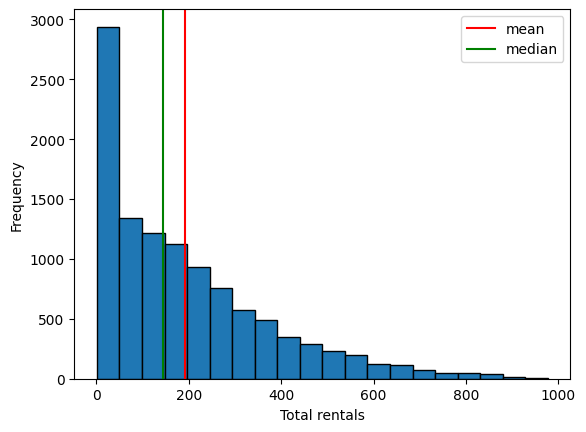

In [44]:
import matplotlib.pyplot as plt

plt.hist(df['count'], edgecolor='black', bins=20)
plt.xlabel('Total rentals')
plt.ylabel('Frequency')

mean = np.mean(df['count'])
median = np.median(df['count'])

plt.axvline(mean, c='red')
plt.axvline(median, c='green')
plt.legend(['mean', 'median'])


print("Mean:", mean)
print("Median:", median)

plt.show()

The histogram of the target variable was examined to understand its distribution and detect potential outliers.

Key observations:
- The distribution is **positively skewed (right-skewed)**.
- No significant outliers were detected.
- The **mean is approximately 32% higher than the median**, indicating the presence of skewness.

Based on these observations, the **median** is considered a more reliable measure of central tendency for this dataset, as it is less affected by skewed distributions.

### 🔧 Datetime Feature Engineering

In [45]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek #-> Monday=0, Sunday=6
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

The `datetime` feature was converted to a proper datetime format to enable time-based analysis.

From this feature, several new variables were extracted:
- **Hour** → to capture hourly patterns in demand
- **Day of Week** → to identify differences between weekdays and weekends
- **Month** → to capture seasonal trends
- **Year** → to account for long-term changes over time

These engineered features help the model better understand temporal patterns and improve prediction performance.

### 🏷️ Categorical Mapping for Analysis

In [46]:
season_map = {1:'Winter', 2:'Winter', 12:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Fall', 10:'Fall', 11:'Fall'}

weather_map = {1:'Clear', 2:'Mist', 3:'Light Rain', 4:'Heavy Rain'}

dayofweek_map = {0:'Mon', 1:'Tues', 2:'Wednes', 3:'Thurs', 4:'Fri', 5:'Satur', 6:'Sun'}

df['season_map'] = df['month'].map(season_map)
df['weather_map'] = df['weather'].map(weather_map)
df['dayofweek_map'] = df['dayofweek'].map(dayofweek_map)

The `season` and `weather` features were mapped to their corresponding descriptive labels to improve interpretability during analysis.

Instead of using numerical codes, meaningful category names were used (e.g., Spring, Summer, Clear, Mist), making visualizations and insights easier to understand.

This transformation was applied only for exploratory data analysis and did not affect the original data used for modeling.

In [47]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,dayofweek,month,year,season_map,weather_map,dayofweek_map
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,5,1,2011,Winter,Clear,Satur
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,5,1,2011,Winter,Clear,Satur
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,5,1,2011,Winter,Clear,Satur
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,5,1,2011,Winter,Clear,Satur
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,5,1,2011,Winter,Clear,Satur


### ⛅ Seasonal Impact on Bike Demand

            median     iqr     max
season_map                        
Fall        176.00  271.00  977.00
Spring      134.00  235.75  873.00
Summer      203.00  278.50  897.00
Winter       87.00  153.00  759.00


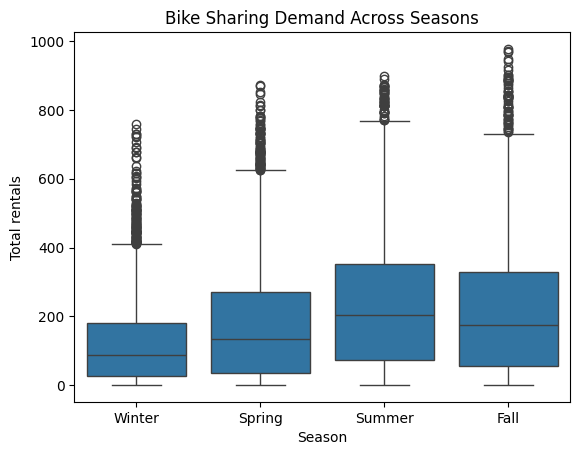

In [48]:
import seaborn as sns
from scipy.stats import iqr

sns.boxplot(x=df['season_map'], y=df['count'])
plt.title('Bike Sharing Demand Across Seasons')
plt.xlabel('Season')
plt.ylabel('Total rentals')

Q1 = df["count"].quantile(0.25)
Q3 = df["count"].quantile(0.75)
IQR = Q3 - Q1

season_impact = df.groupby('season_map')['count'].agg(['median', iqr, 'max'])

print(season_impact.map("{:,.2f}".format))

plt.show()

A boxplot was used to analyze the distribution of bike rentals across different seasons.

Key observation:
- **Summer** shows the highest median rental count compared to other seasons.

This indicates that bike demand tends to peak during the summer season, likely due to more favorable weather conditions and increased outdoor activity.

### 🌧️ Weather Impact on Bike Demand

             median     iqr     max
weather_map                        
Clear        161.00  257.00  977.00
Heavy Rain   164.00    0.00  164.00
Light Rain    71.00  138.00  891.00
Mist         134.00  223.00  890.00


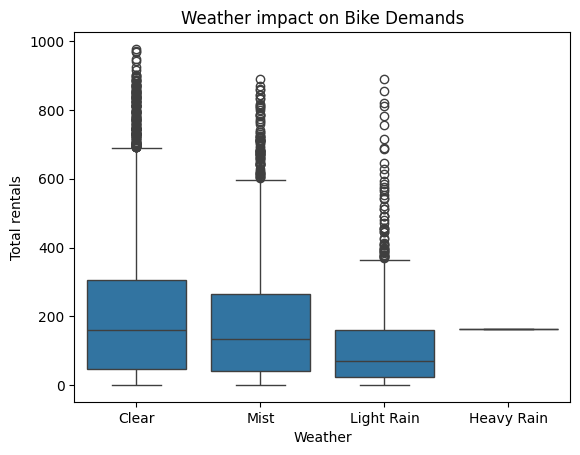

In [49]:
sns.boxplot(x=df['weather_map'], y=df['count'])
plt.title('Weather impact on Bike Demands')
plt.xlabel('Weather')
plt.ylabel('Total rentals')

weather_impact = df.groupby('weather_map')['count'].agg(['median', iqr, 'max'])

print(weather_impact.map("{:,.2f}".format))

plt.show()

A boxplot was used to analyze bike rental distribution across different weather conditions.

Initial observation:
- **Heavy rain** shows the highest median rental count.

However, this result is not reliable because:
- The heavy rain category contains only **one sample**, which is not sufficient for meaningful comparison.

After considering sample size:
- **Clear weather** has the next highest median rental count.
- It also has the **largest number of samples**, making it a more reliable indicator.
- The difference in median between clear weather and other categories is relatively small.

Conclusion:
Clear weather is considered the most representative condition associated with higher bike demand, while the heavy rain result is disregarded due to insufficient data.

In [50]:
df['weather_map'].value_counts()

weather_map
Clear         7192
Mist          2834
Light Rain     859
Heavy Rain       1
Name: count, dtype: int64

### 🔗 Combined Effect of Season and Weather

In [51]:
df.groupby(['season_map', 'weather_map'])['count'].agg(rentals_median ='median', sample_size='count').reset_index() \
.sort_values(by= 'rentals_median', ascending=False)

,season_map,weather_map,rentals_median,sample_size
8,Summer,Mist,213.5,530
6,Summer,Clear,208.0,2053
0,Fall,Clear,191.0,1731
2,Fall,Mist,172.0,744
10,Winter,Heavy Rain,164.0,1
3,Spring,Clear,159.0,1711
5,Spring,Mist,122.0,775
7,Summer,Light Rain,122.0,153
1,Fall,Light Rain,106.0,256
9,Winter,Clear,93.0,1697


To further validate previous findings and check for potential interactions between features, a grouped analysis was performed using both **season** and **weather**.

For each combination, the following were calculated:
- Median rental count
- Number of samples

Key findings:
- The combination **Summer + Mist** shows the highest median rental count.
- However, **Summer + Clear** comes second with a slightly lower median.
- Importantly, **Summer + Clear has approximately 4 times more samples** than Summer + Mist.

Conclusion:
Although Summer + Mist has the highest median, the significantly larger sample size of Summer + Clear makes it a more reliable and representative indicator of high bike demand.

This suggests that both season and weather jointly influence rental patterns, and results should be interpreted with consideration of sample size.

### 📈 Correlation Analysis

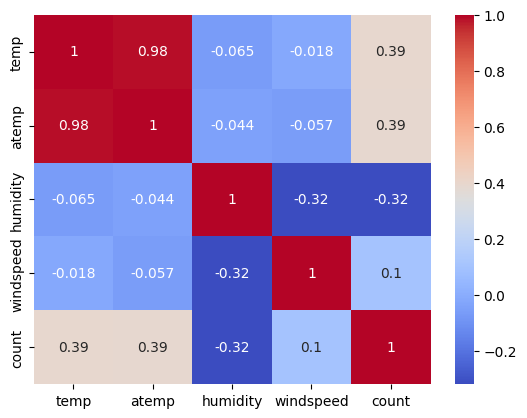

In [52]:
corr =  df[['temp', 'atemp', 'humidity', 'windspeed', 'count']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

A correlation heatmap was used to examine the linear relationships between features and the target variable (`count`).

Key observations:
- No feature showed a particularly strong linear correlation with the target.
- A very high correlation was observed between `temp` and `atemp`.

This indicates that both features carry highly similar information, which may introduce redundancy in the model.

Conclusion:
One of these features can be removed during training to reduce multicollinearity and simplify the feature set.  
Since `atemp` (apparent temperature) is more representative of perceived environmental conditions, it was preferred over `temp`.

In [60]:
df.groupby(
    ['season_map', 'weather_map'], 
    observed=True
)[['humidity', 'windspeed','count']].median().reset_index().sort_values(by='humidity', ascending=False)

,season_map,weather_map,humidity,windspeed,count
1,Fall,Light Rain,88.0,12.9980,106.0
11,Winter,Light Rain,88.0,11.0014,49.5
4,Spring,Light Rain,87.0,15.0013,45.5
10,Winter,Heavy Rain,86.0,6.0032,164.0
7,Summer,Light Rain,82.0,12.9980,122.0
5,Spring,Mist,76.0,12.9980,122.0
2,Fall,Mist,70.5,12.9980,172.0
12,Winter,Mist,69.0,11.0014,90.0
8,Summer,Mist,66.0,11.0014,213.5
0,Fall,Clear,63.0,11.0014,191.0


### 🌡️ Apparent Temperature (atemp) Analysis

In [54]:
pd.qcut(df['atemp'], q=4)

0        (0.759, 16.665]
1        (0.759, 16.665]
2        (0.759, 16.665]
3        (0.759, 16.665]
4        (0.759, 16.665]
              ...       
10881    (16.665, 24.24]
10882    (16.665, 24.24]
10883    (0.759, 16.665]
10884    (16.665, 24.24]
10885    (0.759, 16.665]
Name: atemp, Length: 10886, dtype: category
Categories (4, interval[float64, right]): [(0.759, 16.665] < (16.665, 24.24] < (24.24, 31.06] < (31.06, 45.455]]

In [55]:
df['atemp_category'] = pd.qcut(
    df['atemp'],
    q=4,
    labels = ['Cold', 'Mild', 'Warm', 'Hot']
)

In [ ]:
temp_df = df.groupby(['atemp_category', 'weather_map', 'season_map'], observed=True)['count'] \
.agg(rentals_median='median', sample_size='count').reset_index()

Since the data is well-behaved, no transformation was required.

To facilitate analysis, the continuous `atemp` variable was discretized into categories using **quantile-based binning (qcut)**:

- Cold
- Mild
- Warm
- Hot

Quantile-based binning was chosen to ensure balanced group sizes, avoiding bias that could arise from uneven distributions.

This approach ensures that each category contains a roughly equal number of observations, making comparisons more balanced and interpretable.

### 🔗 Combined Effect of Season, Weather, and Apparent Temperature

In [57]:
temp_df[temp_df['sample_size'] > 100].sort_values(by='rentals_median', ascending=False)

,atemp_category,weather_map,season_map,rentals_median,sample_size
48,Hot,Clear,Fall,352.0,214
50,Hot,Clear,Summer,260.0,1376
33,Warm,Clear,Spring,259.0,586
62,Hot,Mist,Summer,248.5,344
32,Warm,Clear,Fall,230.0,597
45,Warm,Mist,Spring,184.0,299
19,Mild,Clear,Winter,181.0,410
28,Mild,Mist,Fall,171.0,204
44,Warm,Mist,Fall,169.5,326
16,Mild,Clear,Fall,157.0,611


To gain deeper insights, a grouped analysis was performed combining **season**, **weather**, and categorized **atemp**.

For each combination, the following were evaluated:
- Median rental count
- Number of samples

Key findings:
- The combinations **Hot + Clear + Fall** and **Hot + Clear + Summer** show the highest median rental counts.
- However, **Hot + Clear + Summer** has approximately **7 times more samples** than Hot + Clear + Fall.

Conclusion:
Although both combinations exhibit high median demand, **Hot + Clear + Summer** is considered more reliable due to its significantly larger sample size.

This indicates that bike demand tends to peak during **hot, clear days in the summer**, making this combination the most representative high-demand scenario.